# Modeling – Personal selection + KNN – John Bouckaert & Hugo Fiévet

## Introduction

Dans ce notebook, nous appliquons le modèle KNN au jeu de données issu de la sélection personnelle réalisée dans le notebook précédent.

L’objectif est d’évaluer les performances de cette combinaison en suivant une démarche complète : choix d’un indicateur pertinent, entraînement du modèle, optimisation des hyperparamètres, validation croisée, analyse du surapprentissage éventuel et interprétation des résultats.

Cette approche permettra ensuite de comparer cette combinaison avec les autres notebooks de modélisation du travail.

## Table of contents

1. [Loading the selected datasets](#1-loading-the-selected-datasets)  
2. [Choice of the performance metric](#2-choice-of-the-performance-metric)  
3. [Baseline KNN model](#3-baseline-knn-model)  
4. [Hyperparameter tuning with GridSearchCV](#4-hyperparameter-tuning-with-gridsearchcv)  
5. [Cross-validation and performance evaluation](#5-cross-validation-and-performance-evaluation)  
6. [Overfitting and underfitting analysis](#6-overfitting-and-underfitting-analysis)  
7. [Conclusion](#conclusion)

## 1. Loading the selected datasets

Dans cette première étape, nous chargeons les jeux de données correspondant à la sélection personnelle des variables.  

L’objectif est de vérifier que les dimensions des jeux d’entraînement et de test sont cohérentes avant de commencer la modélisation avec le modèle KNN.

In [1]:
import pandas as pd

# Chargement des jeux de données sélectionnés
X_train = pd.read_csv("xtrain_P.csv")
X_test = pd.read_csv("xtest_P.csv")
y_train = pd.read_csv("ytrain.csv")
y_test = pd.read_csv("ytest.csv")

print("Dimensions de X_train :", X_train.shape)
print("Dimensions de X_test :", X_test.shape)
print("Dimensions de y_train :", y_train.shape)
print("Dimensions de y_test :", y_test.shape)

print("\nColonnes de X_train :")
print(X_train.columns.tolist())

print("\nAperçu de X_train :")
print(X_train.head())

Dimensions de X_train : (1047, 15)
Dimensions de X_test : (262, 15)
Dimensions de y_train : (1047, 1)
Dimensions de y_test : (262, 1)

Colonnes de X_train :
['fare', 'has_cabin', 'pclass_1', 'pclass_2', 'pclass_3', 'sex_female', 'sex_male', 'title_grouped_Master', 'title_grouped_Miss', 'title_grouped_Mr', 'title_grouped_Mrs', 'title_grouped_Other', 'family_group_alone', 'family_group_large_family', 'family_group_small_family']

Aperçu de X_train :
       fare  has_cabin  pclass_1  pclass_2  pclass_3  sex_female  sex_male  \
0 -0.499246          0         0         0         1           1         0   
1 -0.090614          0         0         1         0           1         0   
2 -0.017890          0         0         0         1           1         0   
3 -0.509988          0         0         0         1           0         1   
4 -0.501292          0         0         0         1           1         0   

   title_grouped_Master  title_grouped_Miss  title_grouped_Mr  \
0             

Les fichiers correspondant à la sélection personnelle ont bien été chargés et leurs dimensions sont cohérentes. Le jeu d’entraînement contient **1047 observations** et **15 variables**, tandis que le jeu de test contient **262 observations** et les mêmes **15 variables**. Les variables cibles `y_train` et `y_test` ont également été récupérées correctement.

La liste des colonnes confirme que cette combinaison repose sur des variables jugées pertinentes à partir de l’analyse exploratoire. On y retrouve des indicateurs liés au tarif, à la cabine, à la classe, au sexe, au titre et à la structure familiale regroupée. Toutes les variables explicatives sont numériques, ce qui rend le jeu de données directement exploitable pour un modèle KNN.

L’aperçu de `X_train` montre que le jeu de données utilisé pour cette modélisation est propre, homogène et prêt à être soumis au modèle. La prochaine étape consiste à choisir l’indicateur de performance principal qui servira à guider l’évaluation et l’optimisation du modèle.

## 2. Choice of the performance metric

**Dans ce notebook, nous choisissons le F1-score comme indicateur principal de performance.**

Ce choix s’explique par le fait que la variable cible n’est pas parfaitement équilibrée : la proportion de passagers non survivants est plus élevée que celle des survivants. Dans ce contexte, l’accuracy seule pourrait donner une vision trop simplifiée des performances du modèle.

Le F1-score constitue un compromis entre la précision et le rappel. Il permet donc de mieux évaluer la capacité du modèle à identifier correctement les survivants tout en limitant les erreurs de classification. Cet indicateur est particulièrement pertinent lorsque l’on souhaite tenir compte à la fois des faux positifs et des faux négatifs.

## 3. Baseline KNN model

Dans cette étape, nous entraînons un premier modèle KNN avec des paramètres simples afin d’obtenir une référence de départ.

L’objectif est d’évaluer les performances initiales du modèle avant toute optimisation des hyperparamètres. Cette première évaluation servira de point de comparaison pour la suite du notebook.

In [2]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

# y sous forme de vecteur
y_train_series = y_train.iloc[:, 0]
y_test_series = y_test.iloc[:, 0]

# Modèle KNN de base
knn_baseline = KNeighborsClassifier(n_neighbors=5)
knn_baseline.fit(X_train, y_train_series)

# Prédictions
y_pred_baseline = knn_baseline.predict(X_test)

# Évaluation
accuracy_baseline = accuracy_score(y_test_series, y_pred_baseline)
f1_baseline = f1_score(y_test_series, y_pred_baseline)

print("Accuracy du modèle KNN de base :", round(accuracy_baseline, 4))
print("F1-score du modèle KNN de base :", round(f1_baseline, 4))

print("\nMatrice de confusion :")
print(confusion_matrix(y_test_series, y_pred_baseline))

print("\nClassification report :")
print(classification_report(y_test_series, y_pred_baseline))

Accuracy du modèle KNN de base : 0.813
F1-score du modèle KNN de base : 0.738

Matrice de confusion :
[[144  18]
 [ 31  69]]

Classification report :
              precision    recall  f1-score   support

           0       0.82      0.89      0.85       162
           1       0.79      0.69      0.74       100

    accuracy                           0.81       262
   macro avg       0.81      0.79      0.80       262
weighted avg       0.81      0.81      0.81       262



Le modèle KNN de base obtient une **accuracy de 0.813** et un **F1-score de 0.738** sur le jeu de test. Ces résultats montrent que, même sans optimisation particulière, la combinaison entre la sélection personnelle des variables et le modèle KNN fournit déjà des performances correctes.

La matrice de confusion indique que le modèle classe correctement **144 non-survivants** et **69 survivants**. En revanche, il se trompe sur **18 passagers** prédits survivants alors qu’ils ne le sont pas, et surtout sur **31 survivants** prédits à tort comme non-survivants. Le modèle semble donc un peu plus efficace pour reconnaître les non-survivants que les survivants.

Le rapport de classification confirme cette tendance. Pour la classe `0`, le rappel est élevé (**0.89**), ce qui signifie que le modèle identifie bien la majorité des non-survivants. Pour la classe `1`, les résultats sont un peu moins bons, avec un rappel de **0.69** et un F1-score de **0.74**. Cela montre que le modèle manque encore une partie non négligeable des survivants.

Dans l’ensemble, ce premier modèle constitue une base de comparaison satisfaisante. Les performances sont déjà correctes, mais elles laissent encore une marge d’amélioration, en particulier pour mieux détecter la classe des survivants. La prochaine étape consistera donc à optimiser les hyperparamètres du KNN afin d’améliorer cet équilibre.

## 4. Hyperparameter tuning with GridSearchCV

Dans cette étape, nous cherchons à améliorer les performances du modèle KNN en optimisant ses principaux hyperparamètres.

Nous utilisons `GridSearchCV` afin de tester automatiquement plusieurs combinaisons de paramètres et d’identifier celle qui maximise le **F1-score** en validation croisée. Cette démarche permet de choisir un modèle plus adapté que le modèle de base, tout en limitant le risque de choix arbitraire.

In [ ]:
from sklearn.model_selection import GridSearchCV

# Grille d'hyperparamètres
param_grid = {
    "n_neighbors": list(range(1, 32, 2)),
    "weights": ["uniform", "distance"], # Ça dit comment les voisins votent. 
                                        # uniform : Tous les voisins comptent pareil
                                        # distance : les voisins les plus proches comptent davantage
    "metric": ["euclidean", "manhattan"]# comment on mesure la distance entre deux passagers.
}

# GridSearchCV
grid_knn = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1
)

grid_knn.fit(X_train, y_train_series)

print("Meilleurs hyperparamètres :")
print(grid_knn.best_params_)

print("\nMeilleur F1-score moyen en validation croisée :")
print(round(grid_knn.best_score_, 4))

results_knn = pd.DataFrame(grid_knn.cv_results_)
results_knn = results_knn.sort_values(by="rank_test_score").reset_index(drop=True)

print("\nTop 10 des combinaisons testées :")
print(results_knn[[
    "params",
    "mean_test_score",
    "std_test_score",
    "rank_test_score"
]].head(10))

Meilleurs hyperparamètres :
{'metric': 'manhattan', 'n_neighbors': 23, 'weights': 'uniform'}

Meilleur F1-score moyen en validation croisée :
0.7108

Top 10 des combinaisons testées :
                                              params  mean_test_score  \
0  {'metric': 'manhattan', 'n_neighbors': 23, 'we...         0.710753   
1  {'metric': 'manhattan', 'n_neighbors': 27, 'we...         0.708873   
2  {'metric': 'euclidean', 'n_neighbors': 5, 'wei...         0.708679   
3  {'metric': 'manhattan', 'n_neighbors': 5, 'wei...         0.708679   
4  {'metric': 'euclidean', 'n_neighbors': 23, 'we...         0.707668   
5  {'metric': 'manhattan', 'n_neighbors': 31, 'we...         0.705833   
6  {'metric': 'manhattan', 'n_neighbors': 29, 'we...         0.705367   
7  {'metric': 'manhattan', 'n_neighbors': 21, 'we...         0.705003   
8  {'metric': 'manhattan', 'n_neighbors': 25, 'we...         0.704731   
9  {'metric': 'manhattan', 'n_neighbors': 13, 'we...         0.703939   

   std_test_

La recherche par grille montre que la meilleure combinaison d’hyperparamètres est obtenue avec une distance **Manhattan**, un nombre de voisins égal à **23** et une pondération **uniforme**. Ce résultat suggère qu’un modèle KNN relativement lissé, fondé sur un voisinage plus large, généralise mieux qu’un modèle reposant sur très peu de voisins.

Le meilleur **F1-score moyen en validation croisée** est de **0.7108**. Ce score constitue une estimation plus robuste des performances attendues sur de nouvelles données que le simple résultat obtenu sur un seul découpage train/test.

On remarque que plusieurs combinaisons donnent des résultats assez proches, ce qui montre que les performances du KNN restent relativement stables autour des meilleurs réglages. La distance Manhattan apparaît cependant fréquemment parmi les premières positions, ce qui renforce l’idée qu’elle est mieux adaptée ici que la distance euclidienne.

La prochaine étape consiste à évaluer sur le jeu de test le meilleur modèle identifié par `GridSearchCV`, afin de comparer ses performances à celles du modèle de base.

## 5. Performance evaluation

Dans cette étape, nous évaluons sur le jeu de test le meilleur modèle KNN obtenu par optimisation.

L’objectif est de comparer ses performances à celles du modèle de base, en utilisant les mêmes indicateurs : accuracy, F1-score, matrice de confusion et rapport de classification.

In [4]:
# Meilleur modèle trouvé par GridSearchCV
best_knn = grid_knn.best_estimator_

# Prédictions sur le jeu de test
y_pred_best = best_knn.predict(X_test)

# Scores
accuracy_best = accuracy_score(y_test_series, y_pred_best)
f1_best = f1_score(y_test_series, y_pred_best)

print("Accuracy du meilleur modèle KNN :", round(accuracy_best, 4))
print("F1-score du meilleur modèle KNN :", round(f1_best, 4))

print("\nMatrice de confusion :")
print(confusion_matrix(y_test_series, y_pred_best))

print("\nClassification report :")
print(classification_report(y_test_series, y_pred_best))

print("\nRappel des performances du modèle de base :")
print("Accuracy baseline :", round(accuracy_baseline, 4))
print("F1-score baseline :", round(f1_baseline, 4))

Accuracy du meilleur modèle KNN : 0.8435
F1-score du meilleur modèle KNN : 0.7807

Matrice de confusion :
[[148  14]
 [ 27  73]]

Classification report :
              precision    recall  f1-score   support

           0       0.85      0.91      0.88       162
           1       0.84      0.73      0.78       100

    accuracy                           0.84       262
   macro avg       0.84      0.82      0.83       262
weighted avg       0.84      0.84      0.84       262


Rappel des performances du modèle de base :
Accuracy baseline : 0.813
F1-score baseline : 0.738


Le meilleur modèle KNN obtenu par `GridSearchCV` améliore nettement les performances du modèle de base. L’**accuracy** passe de **0.8130** à **0.8435**, tandis que le **F1-score** progresse de **0.7380** à **0.7807**. Cette hausse montre que l’optimisation des hyperparamètres a permis d’obtenir un modèle plus équilibré et plus performant.

La matrice de confusion confirme cette amélioration. Le modèle classe correctement **148 non-survivants** et **73 survivants**, contre respectivement **144** et **69** pour le modèle de base. Le nombre de faux positifs diminue de **18 à 14**, et le nombre de faux négatifs diminue également de **31 à 27**. Le modèle optimisé commet donc moins d’erreurs sur les deux classes.

Le rapport de classification montre que les performances progressent particulièrement pour la classe des survivants (`1`). Le **rappel** passe de **0.69** à **0.73**, et le **F1-score** de cette classe passe de **0.74** à **0.78**. Cela signifie que le modèle repère mieux les survivants qu’au départ, ce qui est important puisque le modèle de base avait justement tendance à en manquer une partie.

Dans l’ensemble, cette optimisation rend le modèle plus satisfaisant. Les performances restent meilleures sur la classe des non-survivants, mais l’écart entre les deux classes se réduit. Le modèle KNN optimisé constitue donc une version plus robuste et plus pertinente que le modèle de base pour cette combinaison de variables.

## 6. Overfitting and underfitting analysis

Dans cette étape, nous comparons les performances du meilleur modèle sur le jeu d’entraînement et sur le jeu de test afin d’évaluer la présence éventuelle de surapprentissage ou de sous-apprentissage.

L’objectif est de vérifier si le modèle généralise correctement, ou s’il obtient des performances trop élevées sur les données d’entraînement par rapport aux données de test.

In [5]:
# Prédictions sur le jeu d'entraînement
y_pred_train = best_knn.predict(X_train)

# Scores sur le train
accuracy_train = accuracy_score(y_train_series, y_pred_train)
f1_train = f1_score(y_train_series, y_pred_train)

print("Performance du meilleur modèle sur le jeu d'entraînement :")
print("Accuracy train :", round(accuracy_train, 4))
print("F1-score train :", round(f1_train, 4))

print("\nPerformance du meilleur modèle sur le jeu de test :")
print("Accuracy test  :", round(accuracy_best, 4))
print("F1-score test  :", round(f1_best, 4))

print("\nÉcart entre train et test :")
print("Écart accuracy :", round(accuracy_train - accuracy_best, 4))
print("Écart F1-score :", round(f1_train - f1_best, 4))


Performance du meilleur modèle sur le jeu d'entraînement :
Accuracy train : 0.808
F1-score train : 0.7302

Performance du meilleur modèle sur le jeu de test :
Accuracy test  : 0.8435
F1-score test  : 0.7807

Écart entre train et test :
Écart accuracy : -0.0355
Écart F1-score : -0.0505


L’analyse des performances sur les jeux d’entraînement et de test ne met pas en évidence de surapprentissage. En effet, si le modèle surapprenait, on s’attendrait à observer des scores nettement meilleurs sur le jeu d’entraînement que sur le jeu de test. Or ici, c’est l’inverse : le modèle obtient une **accuracy de 0.8080** et un **F1-score de 0.7302** sur le jeu d’entraînement, contre **0.8435** et **0.7807** sur le jeu de test.

L’écart observé est donc négatif, aussi bien pour l’accuracy (**-0.0355**) que pour le F1-score (**-0.0505**). Cela signifie que le modèle ne mémorise pas excessivement les données d’entraînement. Ce comportement peut s’expliquer par le fait que le KNN retenu utilise un nombre de voisins relativement élevé (`n_neighbors = 23`), ce qui produit un modèle plus lissé et donc moins sensible au surapprentissage.

Le fait que les performances soient légèrement meilleures sur le jeu de test que sur le jeu d’entraînement peut sembler surprenant, mais ce n’est pas impossible. Cela peut simplement indiquer que le découpage train/test utilisé ici rend le jeu de test un peu plus favorable au modèle que certaines partitions internes du jeu d’entraînement. Ce résultat ne traduit donc pas un problème méthodologique évident.

Dans l’ensemble, ce comportement suggère plutôt un modèle qui généralise correctement. Il ne semble ni fortement surapprendre, ni présenter un sous-apprentissage manifeste, puisque les performances restent satisfaisantes sur le jeu de test après optimisation.

### Learning curve

Afin de compléter l’analyse du surapprentissage et du sous-apprentissage, nous utilisons une courbe d’apprentissage.  
Cette représentation permet d’observer l’évolution des performances du modèle sur le jeu d’entraînement et en validation croisée en fonction de la quantité de données utilisées.

L’objectif est de vérifier si le modèle bénéficie encore d’un apport de données supplémentaires, et d’identifier plus finement un éventuel surapprentissage ou sous-apprentissage.

Résultats de la courbe d'apprentissage :
   train_size  f1_train_mean  f1_train_std  f1_validation_mean  \
0          83         0.6009        0.2528              0.5210   
1         167         0.7033        0.0517              0.6582   
2         251         0.7310        0.0298              0.6970   
3         334         0.6926        0.0182              0.6444   
4         418         0.7089        0.0218              0.6577   
5         502         0.7230        0.0203              0.6784   
6         585         0.7262        0.0256              0.6742   
7         669         0.7239        0.0090              0.7023   
8         753         0.7244        0.0136              0.6980   
9         837         0.7218        0.0056              0.7157   

   f1_validation_std  
0             0.2408  
1             0.0472  
2             0.0370  
3             0.0520  
4             0.0435  
5             0.0567  
6             0.0617  
7             0.0350  
8             0.0272  
9 

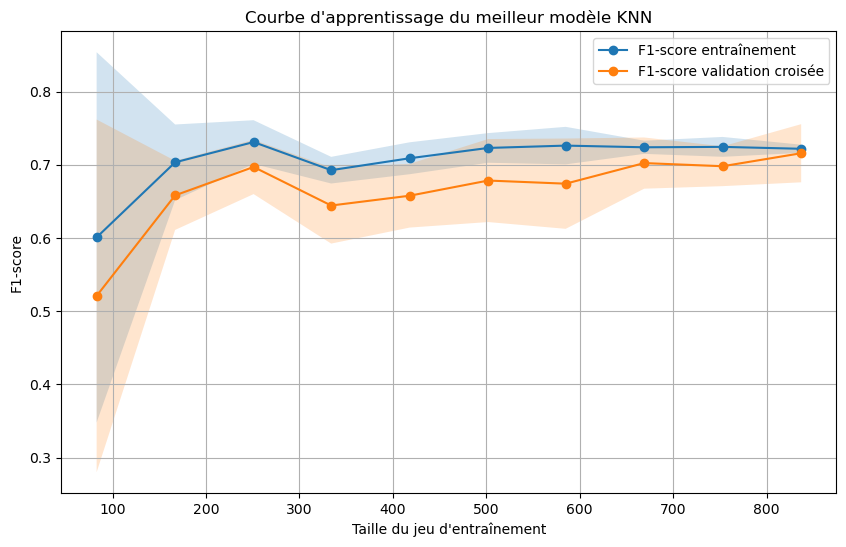

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve

# Calcul de la courbe d'apprentissage
train_sizes, train_scores, val_scores = learning_curve(
    estimator=best_knn,
    X=X_train,
    y=y_train_series,
    cv=5,
    scoring="f1",
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

# Moyennes et écarts-types
train_scores_mean = train_scores.mean(axis=1)
train_scores_std = train_scores.std(axis=1)

val_scores_mean = val_scores.mean(axis=1)
val_scores_std = val_scores.std(axis=1)

# Affichage des résultats numériques
learning_curve_df = pd.DataFrame({
    "train_size": train_sizes,
    "f1_train_mean": train_scores_mean,
    "f1_train_std": train_scores_std,
    "f1_validation_mean": val_scores_mean,
    "f1_validation_std": val_scores_std
})

print("Résultats de la courbe d'apprentissage :")
print(learning_curve_df.round(4))

# Graphique
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_scores_mean, marker="o", label="F1-score entraînement")
plt.plot(train_sizes, val_scores_mean, marker="o", label="F1-score validation croisée")

plt.fill_between(
    train_sizes,
    train_scores_mean - train_scores_std,
    train_scores_mean + train_scores_std,
    alpha=0.2
)

plt.fill_between(
    train_sizes,
    val_scores_mean - val_scores_std,
    val_scores_mean + val_scores_std,
    alpha=0.2
)

plt.title("Courbe d'apprentissage du meilleur modèle KNN")
plt.xlabel("Taille du jeu d'entraînement")
plt.ylabel("F1-score")
plt.legend()
plt.grid(True)
plt.show()

La courbe d’apprentissage montre que le modèle KNN progresse rapidement lorsque la taille du jeu d’entraînement augmente, puis tend à se stabiliser. Pour les plus petites tailles d’échantillon, les scores sont plus instables, comme le montrent les écarts-types élevés. Cela est particulièrement visible pour `train_size = 83`, où les performances varient fortement d’un pli de validation à l’autre.

Lorsque la taille du jeu d’entraînement augmente, le **F1-score sur l’entraînement** et le **F1-score en validation croisée** se rapprochent progressivement. À partir d’environ **650 à 850 observations**, les deux courbes deviennent relativement stables, avec un F1-score d’entraînement proche de **0.72** et un F1-score de validation croisée qui atteint environ **0.70 à 0.72**.

L’écart entre les deux courbes reste modéré sur la fin, ce qui ne suggère pas de surapprentissage important. En effet, si le modèle surapprenait fortement, la courbe d’entraînement resterait nettement au-dessus de la courbe de validation. Ici, les deux courbes convergent progressivement, ce qui indique une capacité de généralisation satisfaisante.

On n’observe pas non plus de sous-apprentissage manifeste. Les scores finaux restent corrects et les deux courbes atteignent un niveau de performance cohérent avec les résultats obtenus précédemment sur le jeu de test. Le modèle semble donc atteindre un compromis raisonnable entre apprentissage et généralisation.

Enfin, la fin de la courbe laisse penser que l’ajout de nouvelles données pourrait encore apporter une légère amélioration, mais probablement sans changement spectaculaire. Le modèle semble déjà proche de son niveau de performance stable pour cette combinaison de variables et d’hyperparamètres.

## Conclusion

Dans ce notebook, nous avons évalué la combinaison entre la sélection personnelle des variables et le modèle KNN.

Le modèle de base a d’abord fourni des résultats corrects, puis l’optimisation des hyperparamètres par `GridSearchCV` a permis d’améliorer sensiblement les performances. Le meilleur modèle obtenu utilise une distance **Manhattan**, un nombre de voisins égal à **23** et une pondération **uniforme**. Sur le jeu de test, ce modèle atteint une **accuracy de 0.8435** et un **F1-score de 0.7807**, ce qui constitue une amélioration nette par rapport au modèle initial.

L’analyse des performances sur les jeux d’entraînement et de test, ainsi que la courbe d’apprentissage, ne mettent pas en évidence de surapprentissage important. Le modèle semble généraliser correctement et atteindre un niveau de performance relativement stable.

Cette combinaison `P + KNN` constitue donc une solution sérieuse pour la prédiction de la survie des passagers du Titanic. Elle servira de point de comparaison pour les autres notebooks de modélisation.